## Modelling

- Data prep
- Null Model
- Accessibility
- Controls
- Interactions
- Well-being models
- Model diagnostics

In [1]:
import sys
sys.path.append("..")
from tqdm import tqdm
tqdm.pandas()
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import re

%load_ext autoreload
%autoreload 2

In [2]:
model_data_df = pd.read_parquet("../data/full_variable_df.parquet")
model_data_df['total_breadth'] = model_data_df['phys_breadth'] + model_data_df['digi_breadth']
model_data_df['total_depth'] = model_data_df['phys_depth'] + model_data_df['digi_depth']

# Normalise to 0–1
for var in ['total_breadth', 'total_depth']:
    model_data_df[f'{var}_norm'] = (
        (model_data_df[var] - model_data_df[var].min()) /
        (model_data_df[var].max() - model_data_df[var].min())
    )

# Intensity
model_data_df['intensity'] = (
    model_data_df['total_breadth_norm'] *
    model_data_df['total_depth_norm']
)

# Standardise proximity
model_data_df['prox_z'] = (
    model_data_df['LAD_agg_proximity'] -
    model_data_df['LAD_agg_proximity'].mean()
) / model_data_df['LAD_agg_proximity'].std()

print(model_data_df[['total_breadth', 'total_depth', 'intensity', 'prox_z']].describe())

       total_breadth  total_depth  intensity        prox_z
count       171748.0     170832.0   170832.0  1.717480e+05
mean       10.170587   168.249058   0.027706  5.907813e-17
std         5.631196    110.74868   0.028932  1.000000e+00
min              0.0          0.0        0.0 -2.780960e+00
25%              6.0         86.0   0.007085 -6.071527e-01
50%             10.0        157.0   0.019854  1.217170e-02
75%             14.0        233.0    0.03924  6.002261e-01
max             39.0       1976.0   0.974359  1.840708e+00


#### Missing Data

In [3]:
# Missing values summary
missing_summary = model_data_df.isnull().sum().to_frame(name='missing_count')
missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(model_data_df)) * 100

print("\nMissing Data Summary:")
print(missing_summary.sort_values(by='missing_pct', ascending=False))


Missing Data Summary:
                    missing_count  missing_pct
EDUCAT2                    129689    75.511214
JOBEVER                    102334    59.583809
EDUCAT4                     26694    15.542539
NSSEC_5                     16852     9.812050
EDUCAT1                     12854     7.484221
Qwork                        6165     3.589561
WELLB4_rev                   5911     3.441670
wellbeing                    3770     2.195077
SEX                          2947     1.715886
AGEBAND                      2820     1.641941
total_depth                   916     0.533340
total_depth_norm              916     0.533340
intensity                     916     0.533340
phys_depth                    512     0.298111
digi_depth                    461     0.268417
total_breadth_norm              0     0.000000
LAD23NM                         0     0.000000
total_breadth                   0     0.000000
LAD_agg_proximity               0     0.000000
ArchYcserial                    0    

In [4]:
# Fill missing as new category
model_data_df['EDUCAT4_filled'] = model_data_df['EDUCAT4'].fillna(-1)
model_data_df['NSSEC_5_filled'] = model_data_df['NSSEC_5'].fillna(-1)

# Convert to categorical
model_data_df['EDUCAT4_filled'] = model_data_df['EDUCAT4_filled'].astype('category')
model_data_df['NSSEC_5_filled'] = model_data_df['NSSEC_5_filled'].astype('category')

In [5]:
# Drop remaining missing values
model_data_df = model_data_df.dropna(subset=[
    'SEX', #1 Female, 2 Male
    'AGEBAND',
    'total_depth',
    # 'wellbeing',
])

#### Numeric Vars Distribution

In [6]:
# Select key numeric variables
numeric_vars = [
    'phys_breadth', 'digi_breadth', 'total_breadth',
    'phys_depth', 'digi_depth', 'total_depth',
    'wellbeing',
    'LAD_agg_proximity'
]

desc_stats = model_data_df[numeric_vars].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

print("\nDescriptive Statistics:")
print(desc_stats)


Descriptive Statistics:
       phys_breadth  digi_breadth  total_breadth  phys_depth  digi_depth  \
count      166458.0      166458.0       166458.0    166458.0    166458.0   
mean       4.285015      5.963456      10.248471   37.325283  131.831273   
std        3.048421      3.314773       5.591209   41.621916   93.073171   
min             0.0           0.0            0.0         0.0         0.0   
1%              0.0           0.0            0.0         0.0         0.0   
5%              0.0           1.0            2.0         0.0         3.0   
50%             4.0           6.0           10.0        20.0       119.0   
95%            10.0          11.0           20.0       116.0       300.0   
99%            13.0          14.0           24.0       170.0       400.0   
max            24.0          16.0           39.0      1144.0       832.0   

       total_depth  wellbeing  LAD_agg_proximity  
count     166458.0   163431.0      166458.000000  
mean    169.156556   7.037664       


Skewness:
phys_depth           2.428039
total_depth          0.970818
digi_depth           0.864162
phys_breadth         0.838688
total_breadth         0.39335
digi_breadth         0.172873
LAD_agg_proximity   -0.094896
wellbeing           -0.876913
dtype: Float64
phys_depth: 8.14% zeros
digi_depth: 3.88% zeros
total_depth: 2.09% zeros


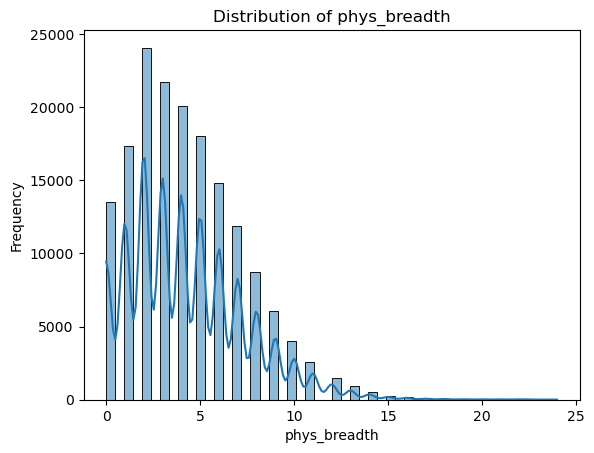

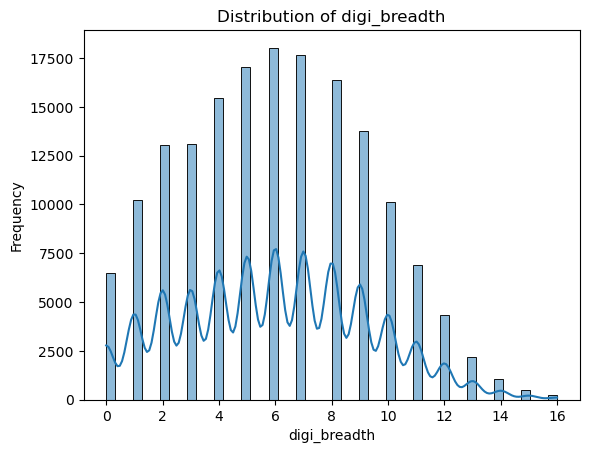

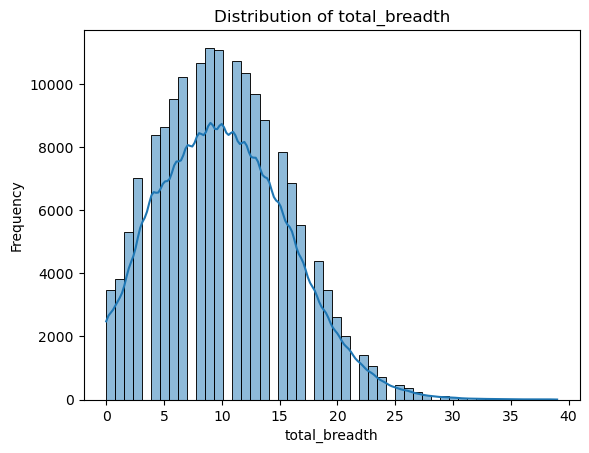

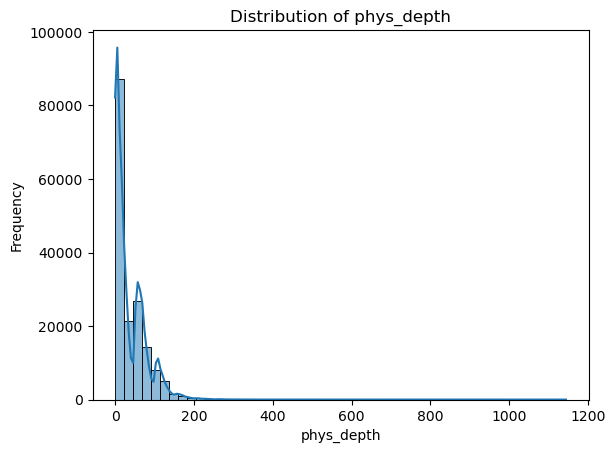

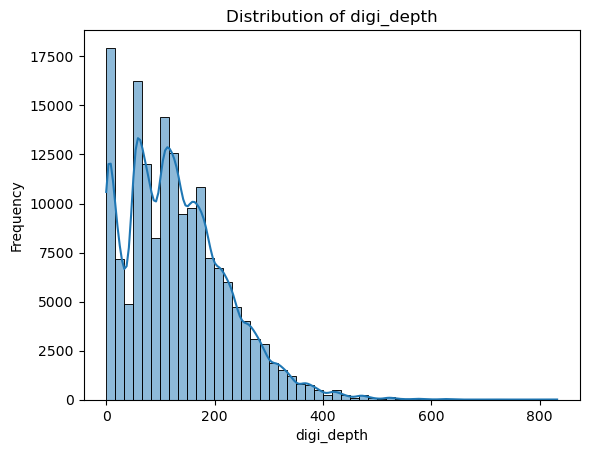

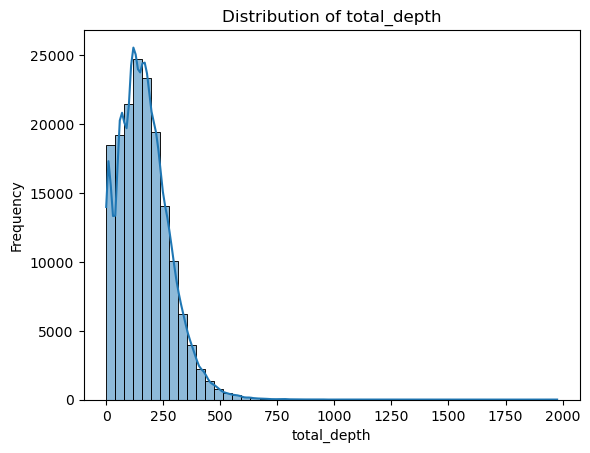

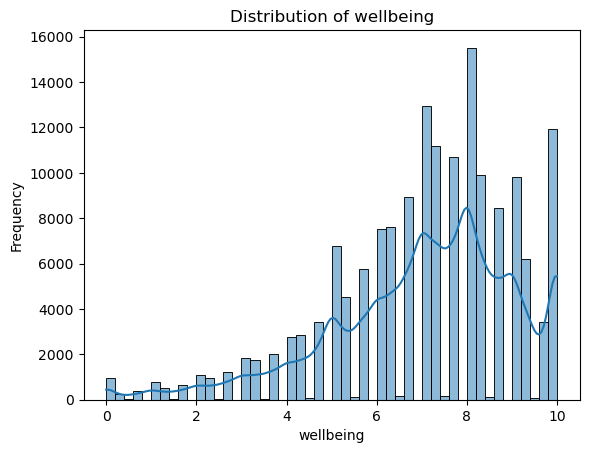

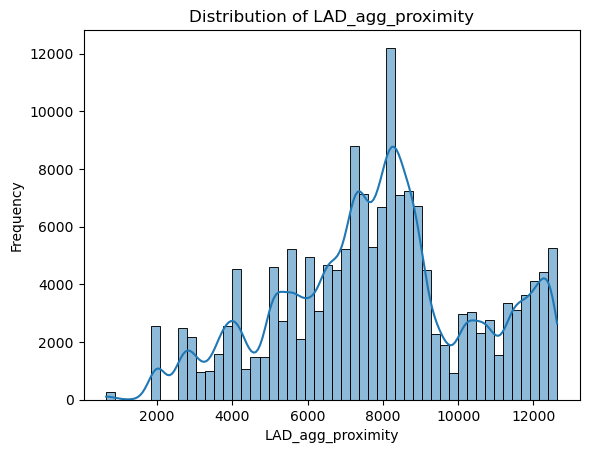

In [7]:
skewness = model_data_df[numeric_vars].skew()
print("\nSkewness:")
print(skewness.sort_values(ascending=False))


# Check for zero inflation 
for var in ['phys_depth', 'digi_depth', 'total_depth']:
    zero_pct = (model_data_df[var] == 0).mean() * 100
    print(f"{var}: {zero_pct:.2f}% zeros")


# Plot distributions
for var in numeric_vars:
    plt.figure()
    sns.histplot(model_data_df[var].dropna(), bins=50, kde=True)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

#### Numerical Var Correlations

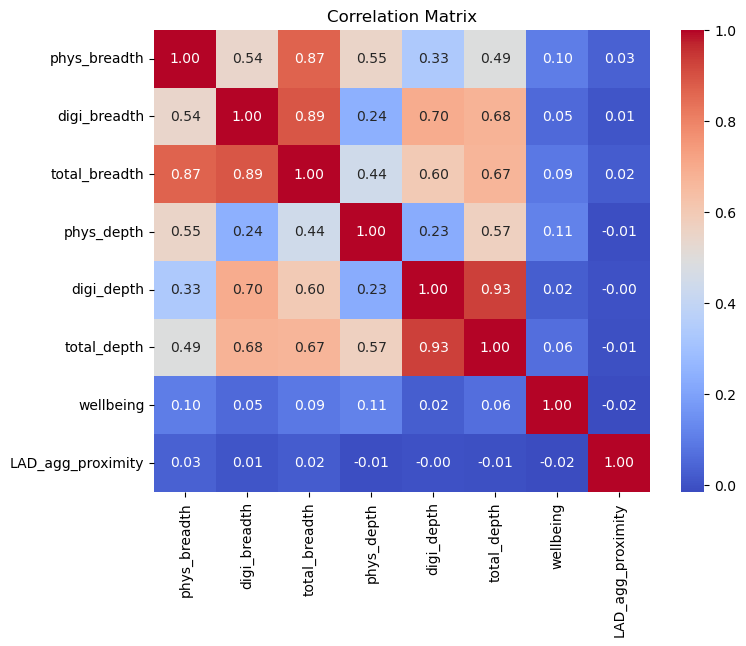

In [8]:
corr_matrix = model_data_df[numeric_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#### Categorical Vars Distribution

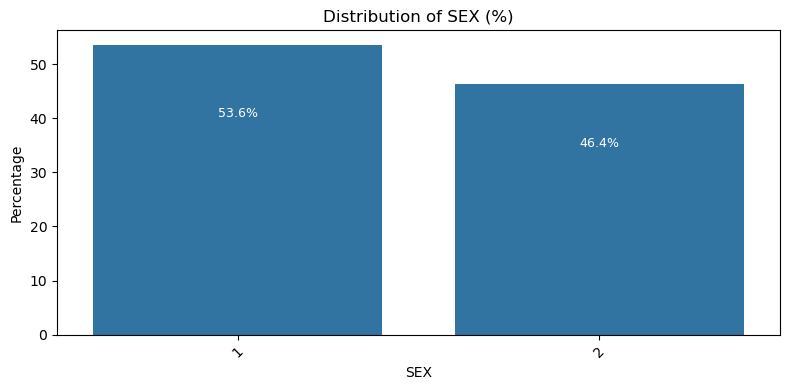

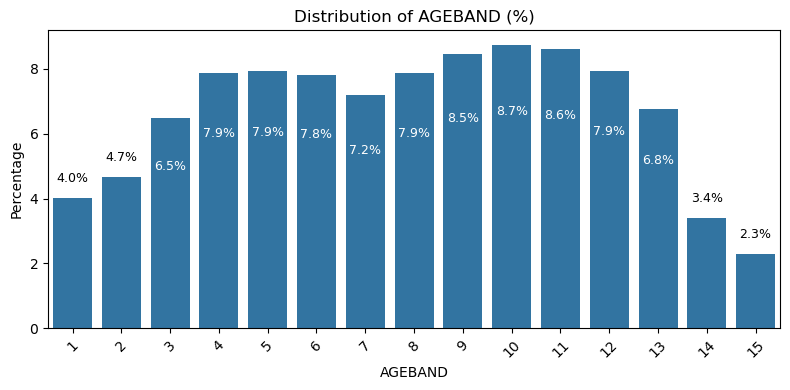

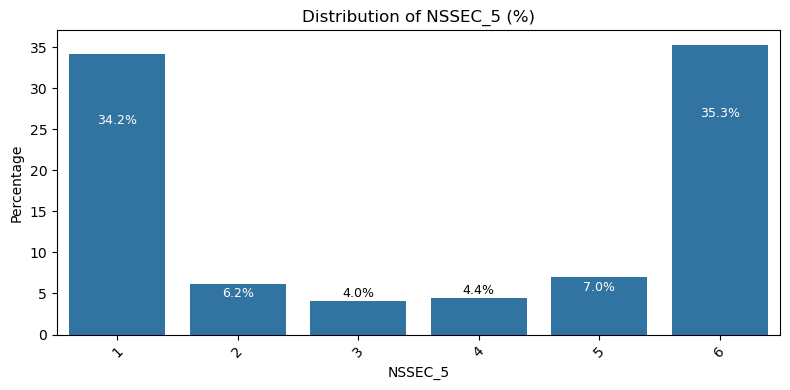

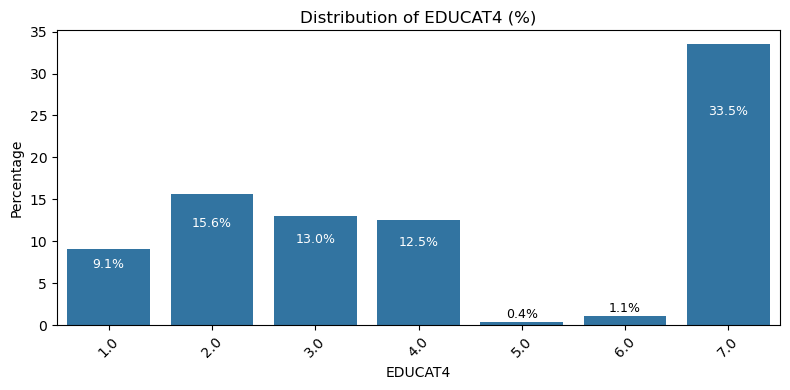

In [9]:
categorical_vars = ['SEX', 'AGEBAND', 'NSSEC_5', 'EDUCAT4']

for var in categorical_vars:
    plt.figure(figsize=(8, 4))
    
    proportions = model_data_df[var].value_counts(normalize=True, dropna=False) * 100
    
    sns.barplot(x=proportions.index, y=proportions.values)
    
    plt.title(f'Distribution of {var} (%)')
    plt.xlabel(var)
    plt.ylabel('Percentage')
    
    # Add labels on bars
    for i, val in enumerate(proportions[proportions.index.dropna()].sort_index().values):
        if val > 5:
            plt.text(i, val*0.75, f"{val:.1f}%", ha='center', fontsize=9, color="#FFFFFF")
        else:
            plt.text(i, val + 0.5, f"{val:.1f}%", ha='center', fontsize=9, color="#000000")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

#### Clean Model Data

In [10]:
select_vars = [
    # DVs
    'total_depth', 'phys_depth', 'digi_depth',
    'total_breadth', 'phys_breadth', 'digi_breadth',
    'wellbeing',

    # IV
    'prox_z',

    # Controls
    'SEX',
    'AGEBAND',
    'EDUCAT4_filled',
    'NSSEC_5_filled',

    # Grouping
    'LAD23CD'
]

final_vars = [
    # DVs
    'total_depth', 'phys_depth', 'digi_depth',
    'total_breadth', 'phys_breadth', 'digi_breadth',
    'wellbeing',

    # IV
    'prox_z',

    # Controls
    'SEX',
    'AGE',
    'EDU',
    'SES',

    # Grouping
    'LAD23CD'
]

clean_model_df = model_data_df.loc[:,select_vars].copy()
clean_model_df.columns = final_vars

categorical_vars = [
    'SEX',
    'AGE',
    'EDU',
    'SES'
]

for var in categorical_vars:
    clean_model_df[var] = clean_model_df[var].astype('category')

print( clean_model_df.info() )
clean_model_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 166458 entries, 0 to 171747
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   total_depth    166458 non-null  Int64   
 1   phys_depth     166458 non-null  Int64   
 2   digi_depth     166458 non-null  Int64   
 3   total_breadth  166458 non-null  Int64   
 4   phys_breadth   166458 non-null  Int64   
 5   digi_breadth   166458 non-null  Int64   
 6   wellbeing      163431 non-null  Float64 
 7   prox_z         166458 non-null  float64 
 8   SEX            166458 non-null  category
 9   AGE            166458 non-null  category
 10  EDU            166458 non-null  category
 11  SES            166458 non-null  category
 12  LAD23CD        166458 non-null  object  
dtypes: Float64(1), Int64(6), category(4), float64(1), object(1)
memory usage: 14.4+ MB
None


,total_depth,phys_depth,digi_depth,total_breadth,phys_breadth,digi_breadth,wellbeing,prox_z,SEX,AGE,EDU,SES,LAD23CD
0,193,7,186,11,4,7,6.333333,-0.494516,1,4,1.0,1,E08000011
1,16,13,3,3,2,1,8.0,-1.157271,2,5,7.0,1,E07000108
2,308,92,216,23,11,12,7.666667,1.732098,2,3,1.0,-1,E09000030
3,206,9,197,14,5,9,2.666667,-1.395713,2,3,7.0,1,E07000148
4,169,30,139,18,9,9,7.333333,-1.395713,1,2,4.0,1,E07000148


In [11]:
### Check missingness again
(clean_model_df==-1).apply(pd.Series.value_counts, normalize=True).T

,False,True
total_depth,1.0,<NA>
phys_depth,1.0,<NA>
digi_depth,1.0,<NA>
total_breadth,1.0,<NA>
phys_breadth,1.0,<NA>
digi_breadth,1.0,<NA>
wellbeing,1.0,<NA>
prox_z,1.0,NaN
SEX,1.0,NaN
AGE,1.0,NaN


--- Proportions for SEX ---
SEX
1    53.612323
2    46.387677
Name: proportion, dtype: float64




SEX
1    89242
2    77216
Name: count, dtype: int64

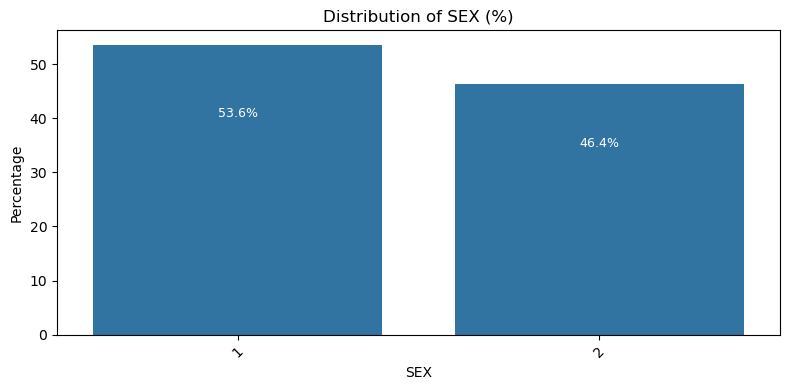




--- Proportions for AGE ---
AGE
1     4.011823
2     4.653426
3     6.491728
4     7.860241
5     7.918514
6     7.812181
7     7.184395
8     7.869252
9     8.462195
10    8.748753
11    8.603371
12    7.938339
13    6.752454
14    3.405664
15    2.287664
Name: proportion, dtype: float64




AGE
1      6678
2      7746
3     10806
4     13084
5     13181
6     13004
7     11959
8     13099
9     14086
10    14563
11    14321
12    13214
13    11240
14     5669
15     3808
Name: count, dtype: int64

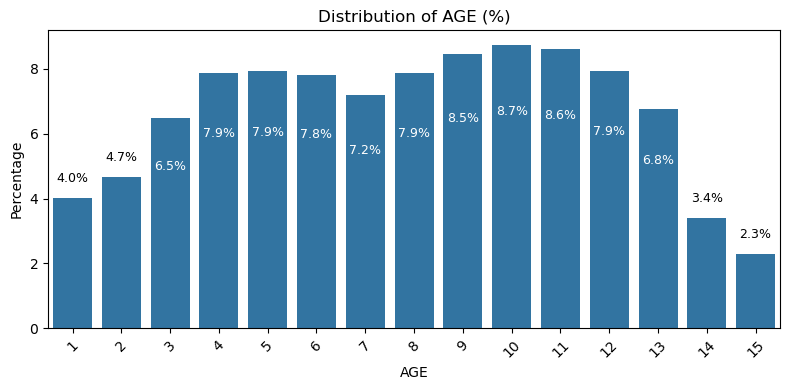




--- Proportions for EDU ---
EDU
-1.0    14.802533
 1.0     9.130832
 2.0    15.581708
 3.0    12.995470
 4.0    12.514268
 5.0     0.406709
 6.0     1.088563
 7.0    33.479917
Name: proportion, dtype: float64




EDU
-1.0    24640
 1.0    15199
 2.0    25937
 3.0    21632
 4.0    20831
 5.0      677
 6.0     1812
 7.0    55730
Name: count, dtype: int64

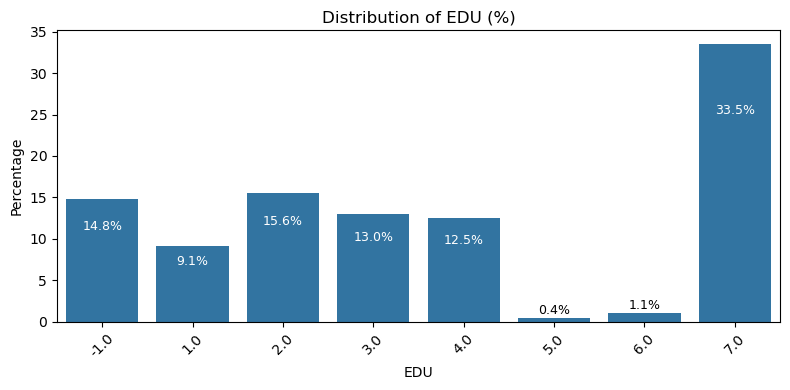




--- Proportions for SES ---
SES
-1     8.915763
 1    34.180394
 2     6.170926
 3     4.027442
 4     4.394502
 5     7.023994
 6    35.286979
Name: proportion, dtype: float64




SES
-1    14841
 1    56896
 2    10272
 3     6704
 4     7315
 5    11692
 6    58738
Name: count, dtype: int64

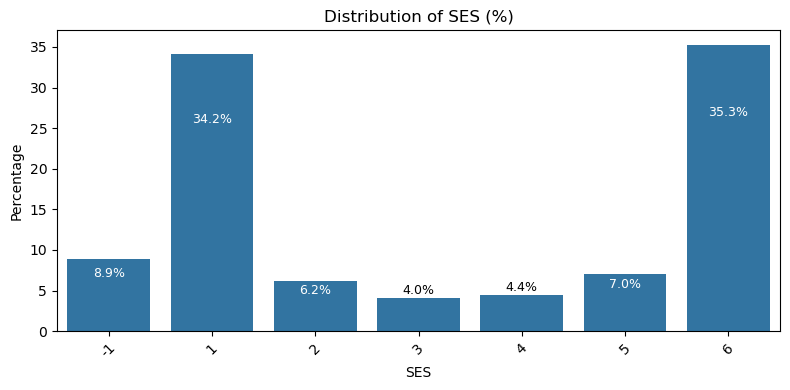

In [12]:
for col in clean_model_df.select_dtypes(include=['category']):
    print(f"--- Proportions for {col} ---")
    print(clean_model_df[col].value_counts(normalize=True).sort_index() * 100)
    print("\n")

    plt.figure(figsize=(8, 4))
    
    display( clean_model_df[col].value_counts(normalize=False, dropna=False).sort_index() )
    proportions = clean_model_df[col].value_counts(normalize=True, dropna=False) * 100
    
    sns.barplot(x=proportions.index, y=proportions.values)
    
    plt.title(f'Distribution of {col} (%)')
    plt.xlabel(col)
    plt.ylabel('Percentage')
    
    # Add labels on bars
    for i, val in enumerate(proportions[proportions.index.dropna()].sort_index().values):
        if val > 5:
            plt.text(i, val*0.75, f"{val:.1f}%", ha='center', fontsize=9, color="#FFFFFF")
        else:
            plt.text(i, val + 0.5, f"{val:.1f}%", ha='center', fontsize=9, color="#000000")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print("\n\n")

In [13]:
### Calculate participation intensity 
# Normalize to 0–1 scale
clean_model_df['breadth_norm'] = (clean_model_df['total_breadth'] - clean_model_df['total_breadth'].min()) \
                                / (clean_model_df['total_breadth'].max() - clean_model_df['total_breadth'].min())

clean_model_df['depth_norm'] = (clean_model_df['total_depth'] - clean_model_df['total_depth'].min()) \
                                / (clean_model_df['total_depth'].max() - clean_model_df['total_depth'].min())

clean_model_df['intensity'] = clean_model_df['breadth_norm'] * clean_model_df['depth_norm']

clean_model_df.loc[:,['total_breadth', 'total_depth', 'intensity']].describe()

,total_breadth,total_depth,intensity
count,166458.0,166458.0,166458.0
mean,10.248471,169.156556,0.027848
std,5.591209,110.34747,0.028844
min,0.0,0.0,0.0
25%,6.0,88.0,0.007267
50%,10.0,158.0,0.020126
75%,14.0,234.0,0.039487
max,39.0,1976.0,0.974359


In [14]:
clean_model_df.loc[:,['prox_z']].describe()

,prox_z
count,166458.000000
mean,-0.006297
std,0.998079
min,-2.780960
25%,-0.667443
50%,0.012172
75%,0.600226
max,1.840708


In [15]:
clean_model_df.loc[:,['wellbeing']].describe()

,wellbeing
count,163431.0
mean,7.037664
std,2.04259
min,0.0
25%,6.0
50%,7.333333
75%,8.333333
max,10.0


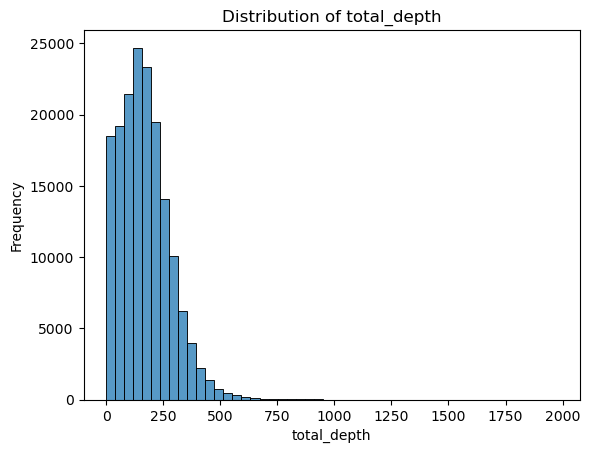

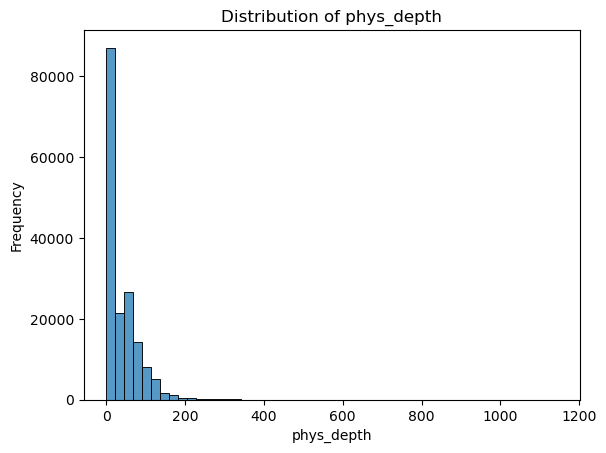

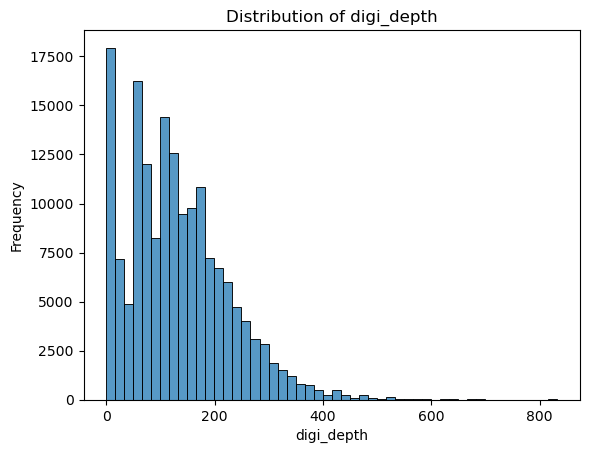

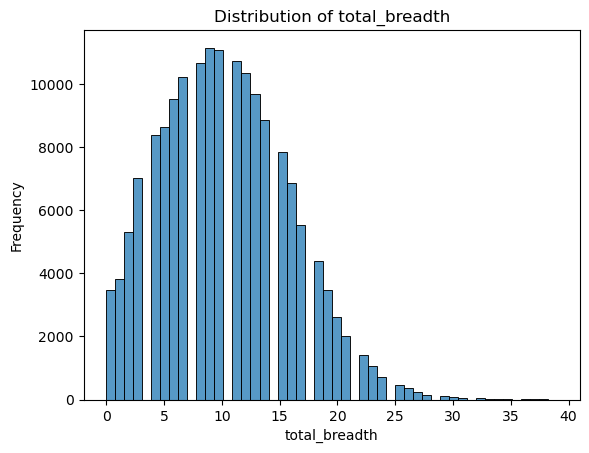

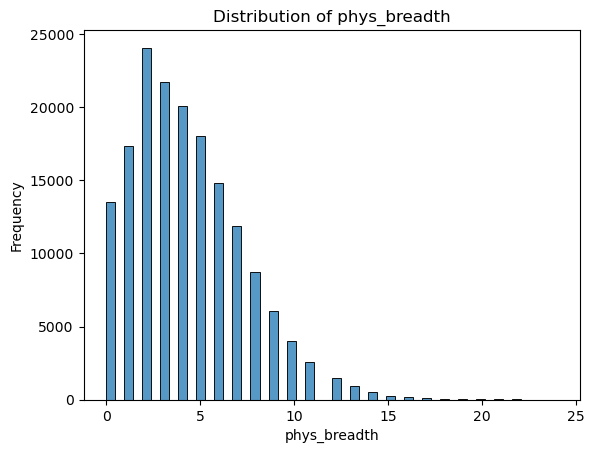

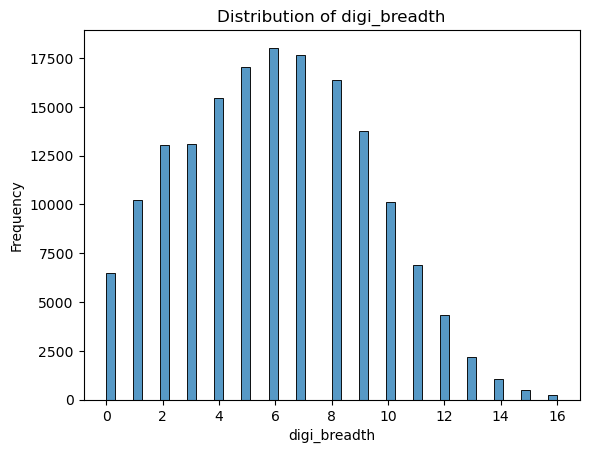

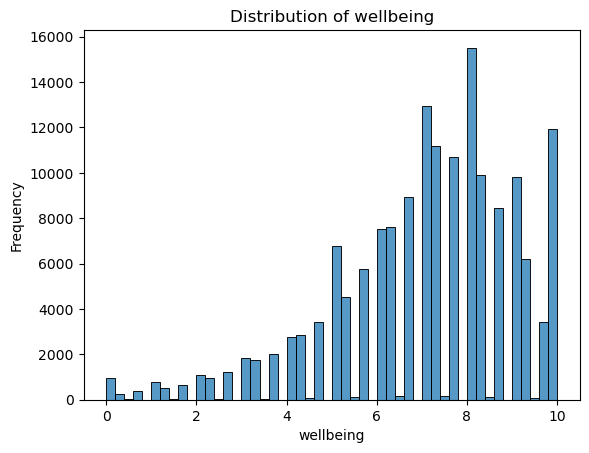

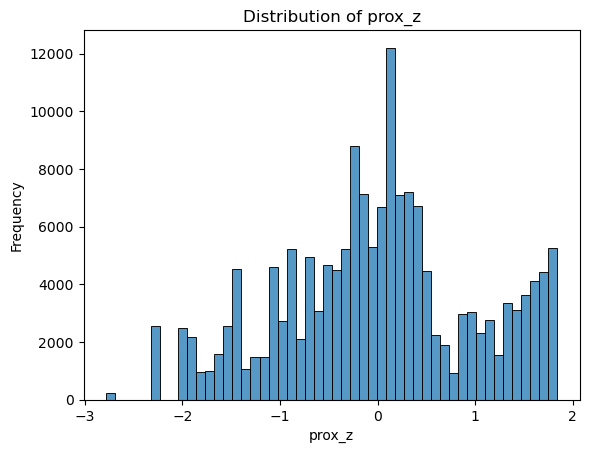

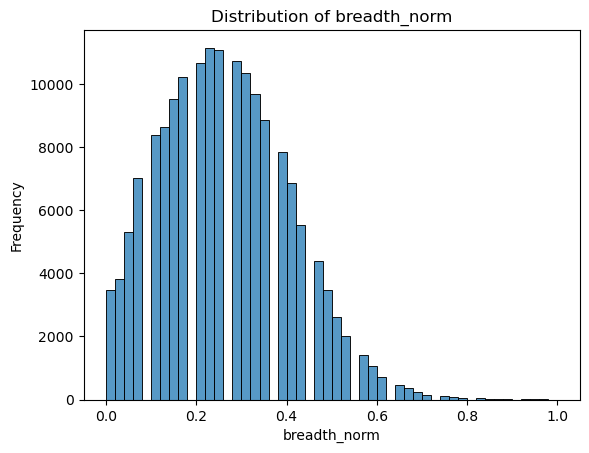

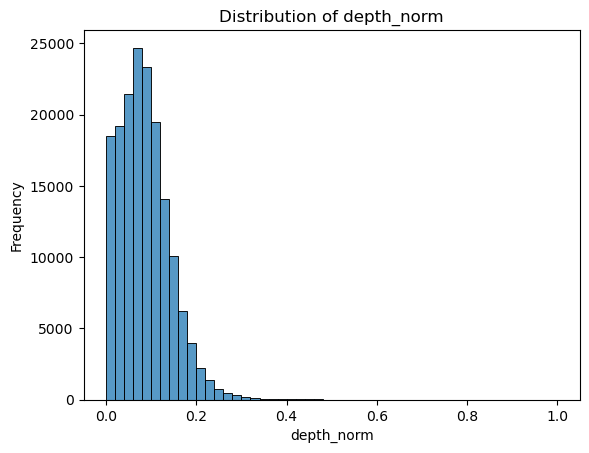

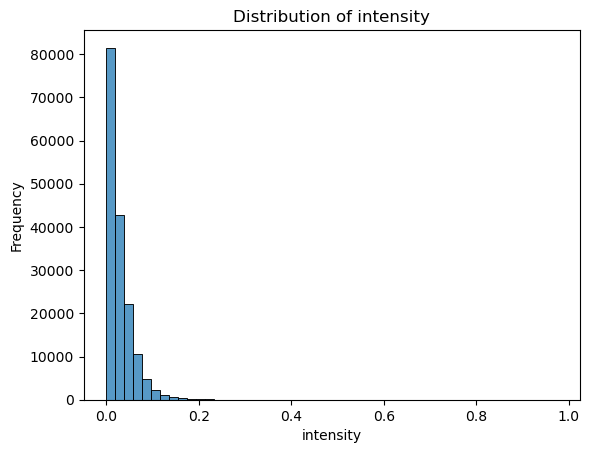

In [16]:
# Plot distributions
for col in clean_model_df.select_dtypes(include=['int', 'float']):
    plt.figure()
    sns.histplot(clean_model_df[col].dropna(), bins=50, kde=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Model Construction

Model 0a: NULL - total_depth

Model 0b: NULL - total_breadth

In [17]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [18]:
# Null model with random intercept for LAD
model_0a = smf.mixedlm(
    "total_depth ~ 1",
    data=clean_model_df,
    groups=clean_model_df["LAD23CD"]
).fit()

print(model_0a.summary())

model_0b = smf.mixedlm(
    "total_breadth ~ 1",
    data=clean_model_df,
    groups=clean_model_df["LAD23CD"]
).fit()

print(model_0b.summary())


           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: total_depth  
No. Observations: 166458  Method:             REML         
No. Groups:       296     Scale:              12003.1329   
Min. group size:  250     Log-Likelihood:     -1018281.1708
Max. group size:  3420    Converged:          Yes          
Mean group size:  562.4                                    
-----------------------------------------------------------
              Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-----------------------------------------------------------
Intercept    169.234    0.828 204.425 0.000 167.612 170.857
Group Var    179.732    0.153                              

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: total_breadth
No. Observations: 166458  Method:             REML         
No. Groups:       296     Scale:              30.2468      
Min. group size:  250     Log-Likelihood:     -520398.7903 
M

In [19]:
# Extract variance components
def model_icc(model):
    var_lad = model.cov_re.iloc[0, 0]
    var_resid = model.scale

    ICC = var_lad / (var_lad + var_resid)

    return(ICC)

print("Dependent Variable: total_depth\nICC = ", "{:0.2f}%".format(model_icc(model_0a)*100))
print("Dependent Variable: total_breadth\nICC = ", "{:0.2f}%".format(model_icc(model_0b)*100))

Dependent Variable: total_depth
ICC =  1.48%
Dependent Variable: total_breadth
ICC =  3.45%


#### Proximity - Negative Binomial Model

Model 1a: total_depth ~ prox_z

Model 1b: total_breadth ~ prox_z

In [20]:
model_1a = smf.glm(
    formula="total_depth ~ prox_z",
    data=clean_model_df,
    family=sm.families.NegativeBinomial()
).fit()

print(model_1a.summary())

model_1b = smf.glm(
    formula="total_breadth ~ prox_z",
    data=clean_model_df,
    family=sm.families.NegativeBinomial()
).fit()

print(model_1b.summary())

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:            total_depth   No. Observations:               166458
Model:                            GLM   Df Residuals:                   166456
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0210e+06
Date:                Sun, 21 Jun 2026   Deviance:                   1.2809e+05
Time:                        23:37:11   Pearson chi2:                 7.04e+04
No. Iterations:                     5   Pseudo R-squ. (CS):          1.096e-05
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1308      0.002   2087.126      0.0

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:          total_breadth   No. Observations:               166458
Model:                            GLM   Df Residuals:                   166456
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.6169e+05
Date:                Sun, 21 Jun 2026   Deviance:                       67297.
Time:                        23:37:12   Pearson chi2:                 4.51e+04
No. Iterations:                     5   Pseudo R-squ. (CS):          0.0001259
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.3271      0.003    906.250      0.0

### Controls

Model 2a: total_depth ~ prox_z 
    + C(SEX) + C(AGE)
    + C(EDU) + C(SES)

Model 2b: total_breadth ~ prox_z
    + C(SEX) + C(AGE)
    + C(EDU) + C(SES)

In [21]:
model_2a = smf.glm(
    formula="""
    total_depth ~ prox_z
    + C(SEX) + C(AGE)
    + C(EDU, Treatment(reference=7.0)) + C(SES, Treatment(reference=6.0))
    """,
    data=clean_model_df,
    family=sm.families.NegativeBinomial()
).fit()

print(model_2a.summary())

model_2b = smf.glm(
    formula="""
    total_breadth ~ prox_z
    + C(SEX) + C(AGE)
    + C(EDU, Treatment(reference=7.0)) + C(SES, Treatment(reference=6.0))
    """,
    data=clean_model_df,
    family=sm.families.NegativeBinomial()
).fit()

print(model_2b.summary())

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:            total_depth   No. Observations:               166458
Model:                            GLM   Df Residuals:                   166428
Model Family:        NegativeBinomial   Df Model:                           29
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.0194e+06
Date:                Sun, 21 Jun 2026   Deviance:                   1.2489e+05
Time:                        23:37:15   Pearson chi2:                 7.14e+04
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01909
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

/opt/miniconda3/envs/thesis/lib/python3.11/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:          total_breadth   No. Observations:               166458
Model:                            GLM   Df Residuals:                   166428
Model Family:        NegativeBinomial   Df Model:                           29
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -5.5897e+05
Date:                Sun, 21 Jun 2026   Deviance:                       61870.
Time:                        23:37:17   Pearson chi2:                 4.33e+04
No. Iterations:                     6   Pseudo R-squ. (CS):            0.03220
Covariance Type:            nonrobust                                         
                                                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------

### Well-being Linear Regession

Accessibility → Participation → Well-being (indirect)

         ↘

           → Well-being (direct)

In [ ]:
# Create reduced sample (drop missing wellbeing)
wb_model_df = clean_model_df.dropna(subset=['wellbeing'])

print(wb_model_df.shape)

(163431, 16)


In [23]:
# 3a accesibility -> wellbeing total effect
model_3a = smf.ols(
    formula="""
    wellbeing ~ prox_z
                + C(SEX)
                + C(AGE)
                + C(EDU, Treatment(reference=7.0)) 
                + C(SES, Treatment(reference=6.0))
    """,
    data=wb_model_df
).fit()
print(model_3a.summary())

# 3b Controlled by depth
model_3b = smf.ols(
    formula="""
    wellbeing ~ prox_z 
                + total_depth
                + C(SEX)
                + C(AGE)
                + C(EDU, Treatment(reference=7.0))
                + C(SES, Treatment(reference=6.0))
    """,
    data=wb_model_df
).fit()
print(model_3b.summary())

# 3c Controlled by breadth
model_3c = smf.ols(
    formula="""
    wellbeing ~ prox_z 
                + total_breadth
                + C(SEX)
                + C(AGE)
                + C(EDU, Treatment(reference=7.0))
                + C(SES, Treatment(reference=6.0))
    """,
    data=wb_model_df
).fit()
print(model_3c.summary())

                            OLS Regression Results                            
Dep. Variable:              wellbeing   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     284.5
Date:                Sun, 21 Jun 2026   Prob (F-statistic):               0.00
Time:                        23:37:19   Log-Likelihood:            -3.4460e+05
No. Observations:              163431   AIC:                         6.893e+05
Df Residuals:                  163401   BIC:                         6.896e+05
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------

# Save Plots for Reporting

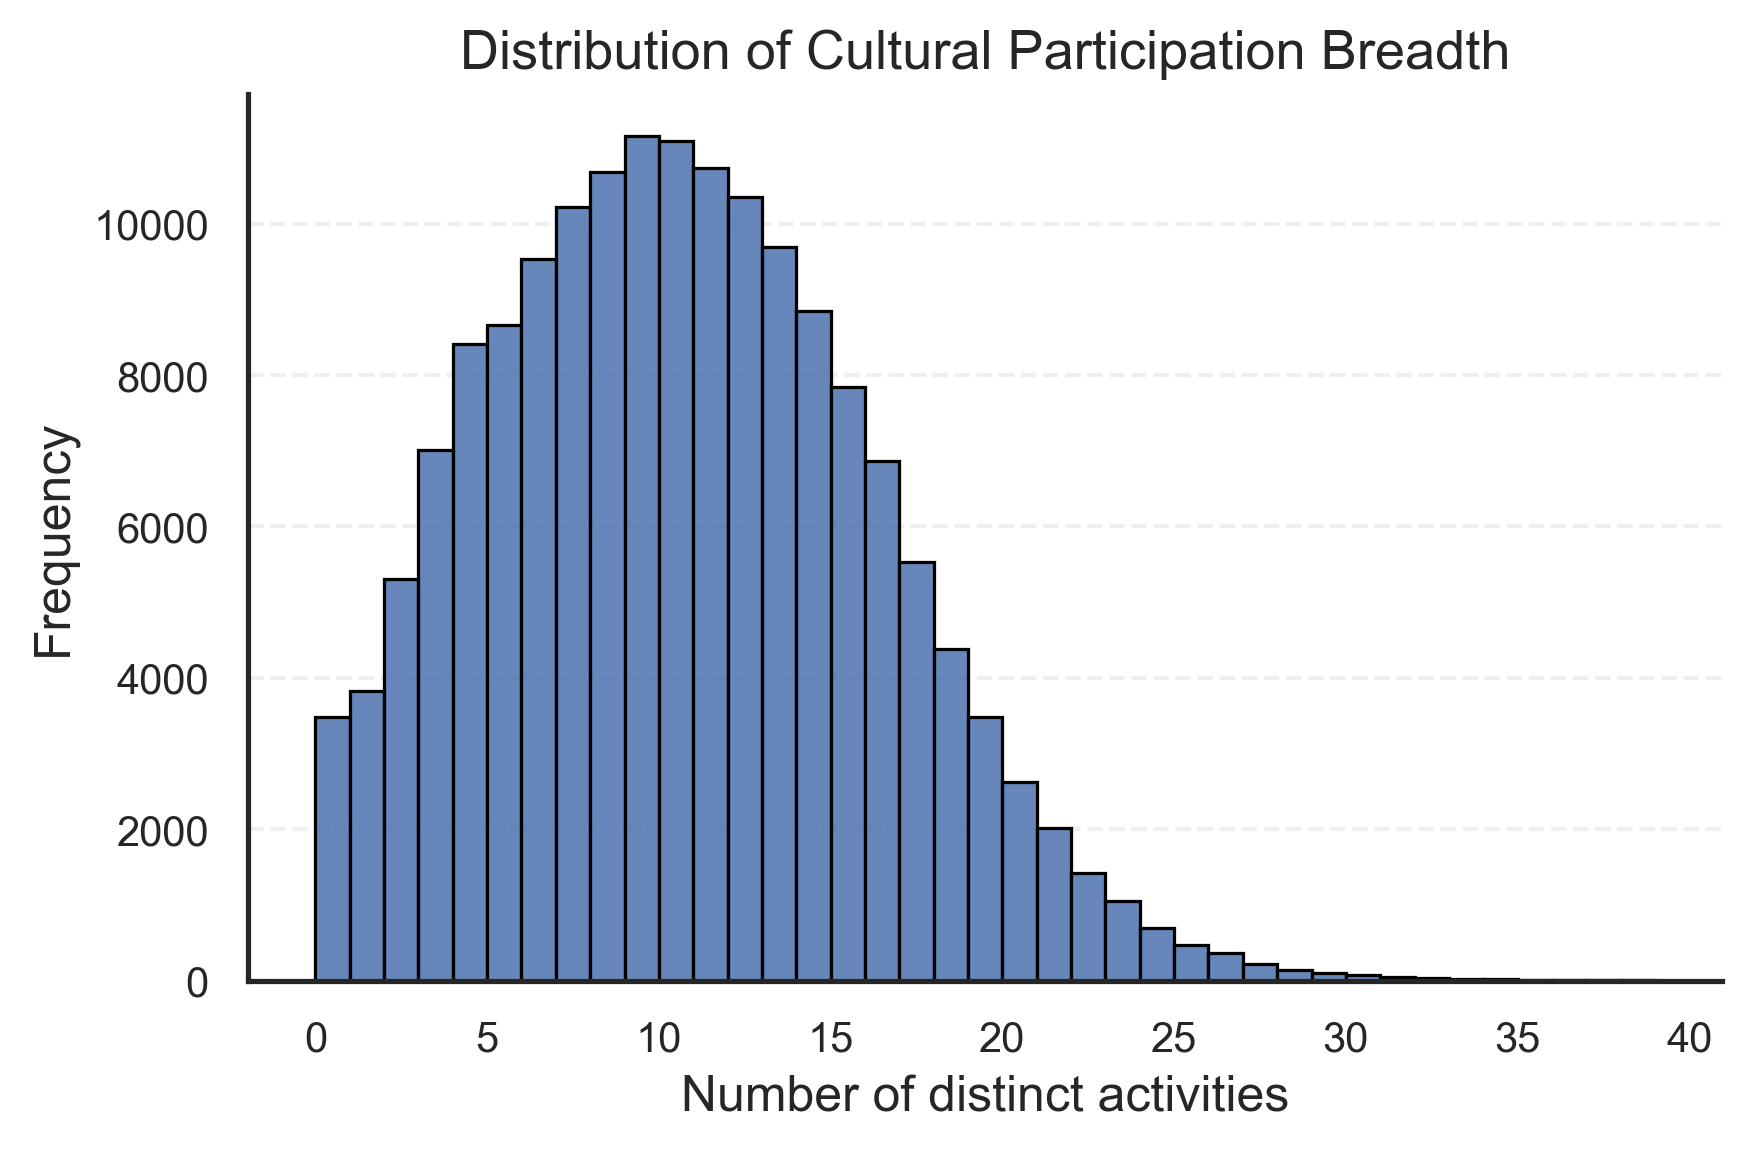

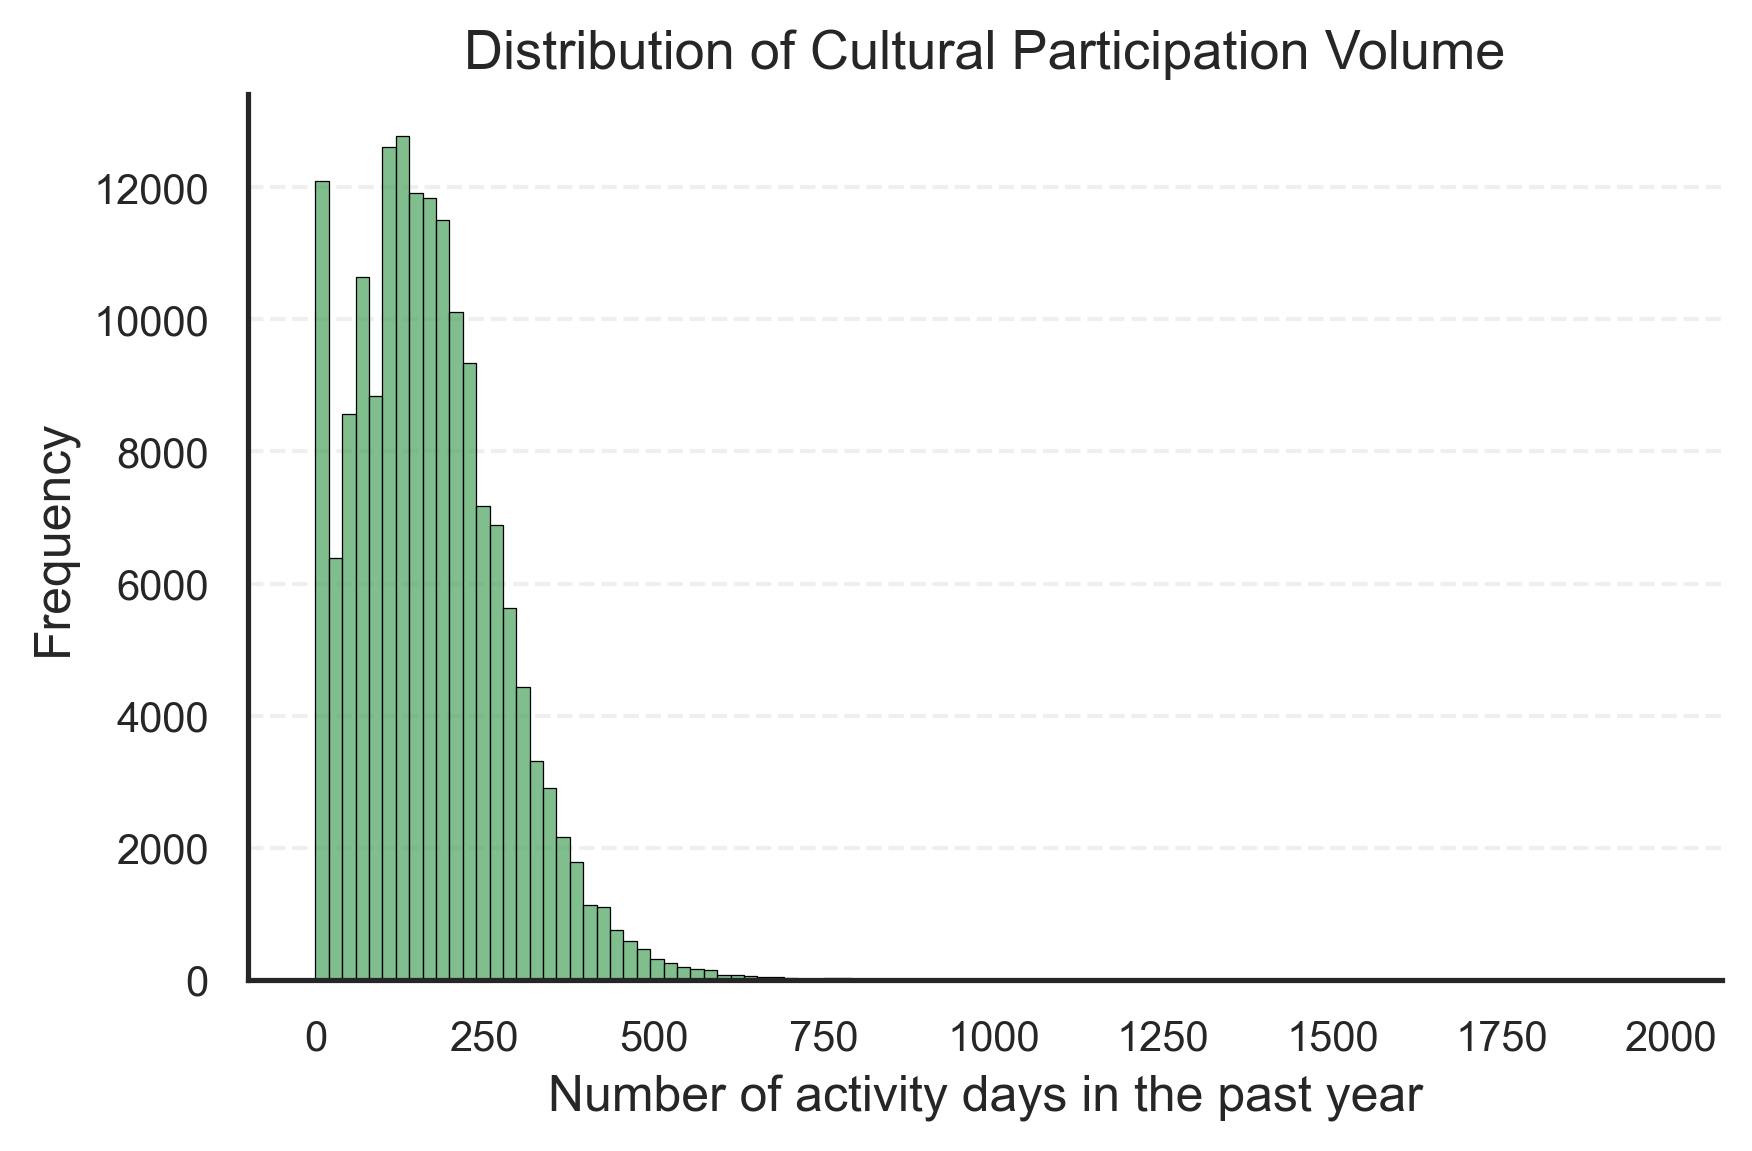

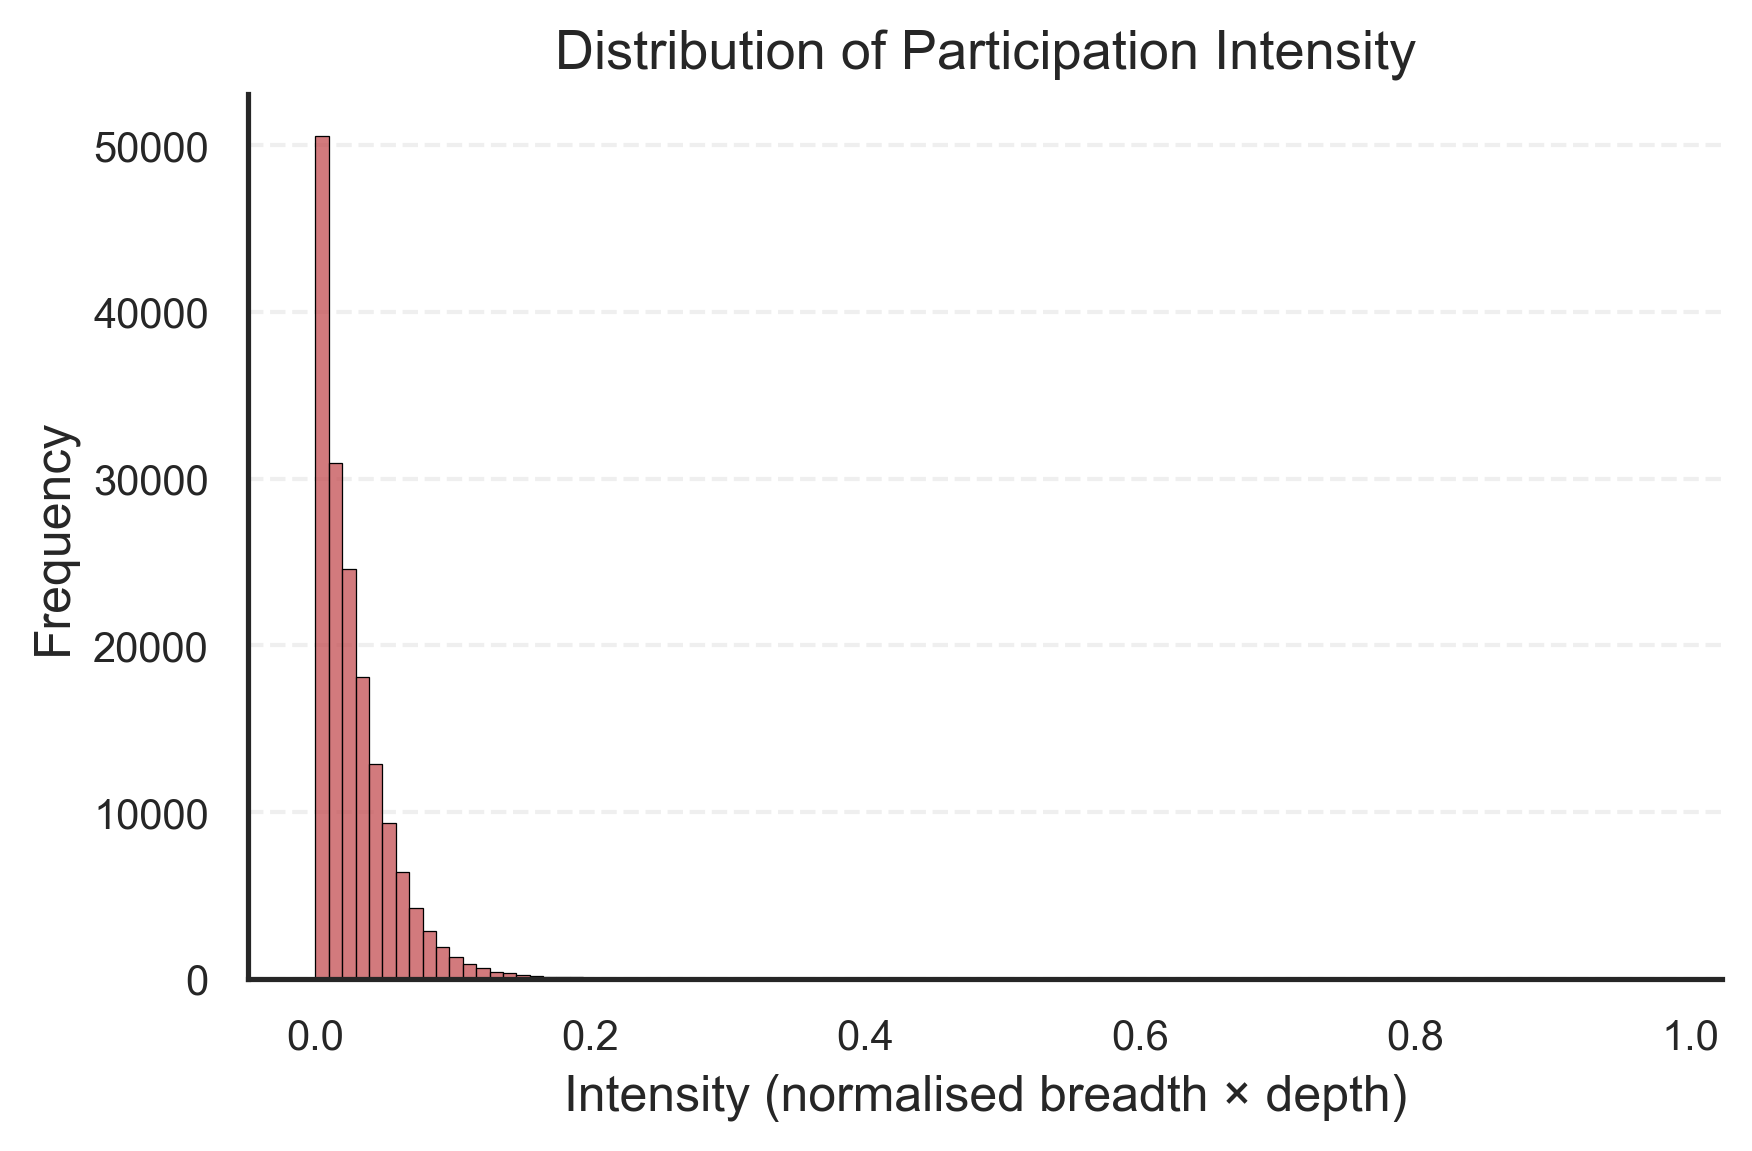

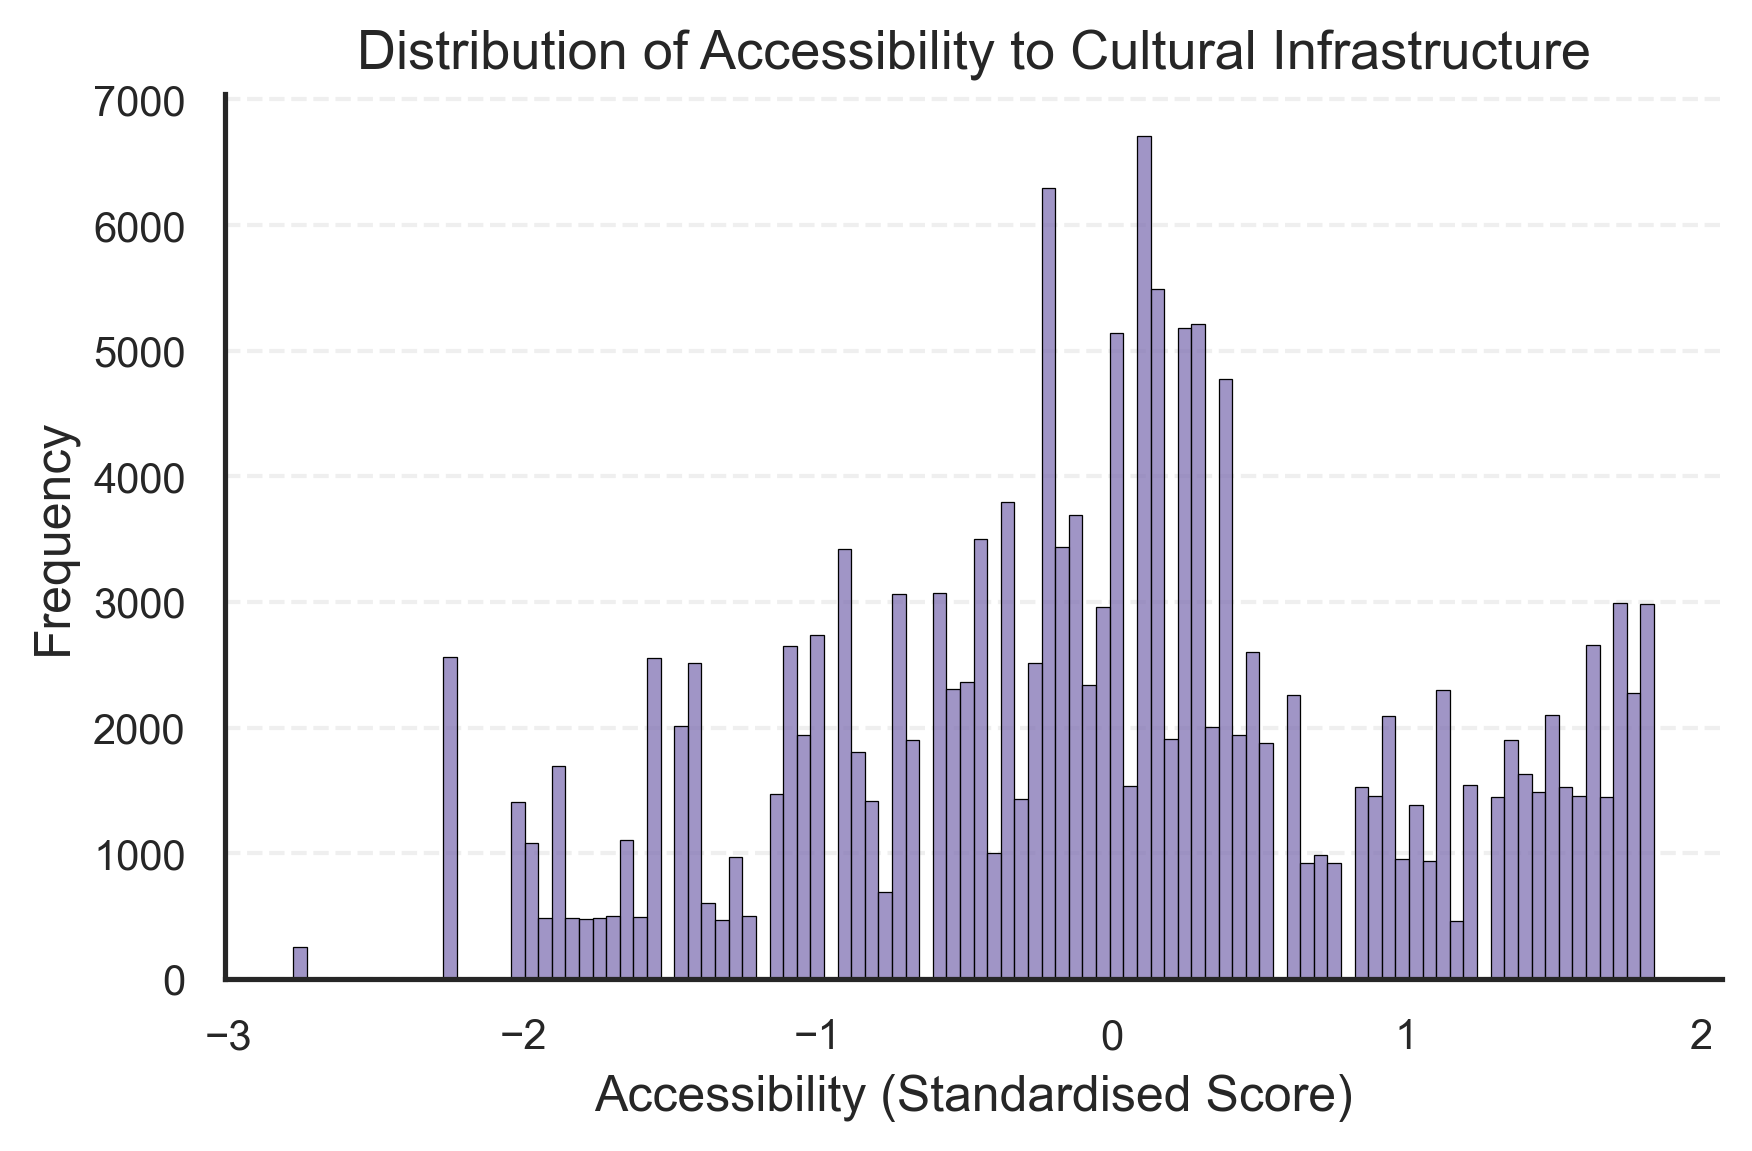

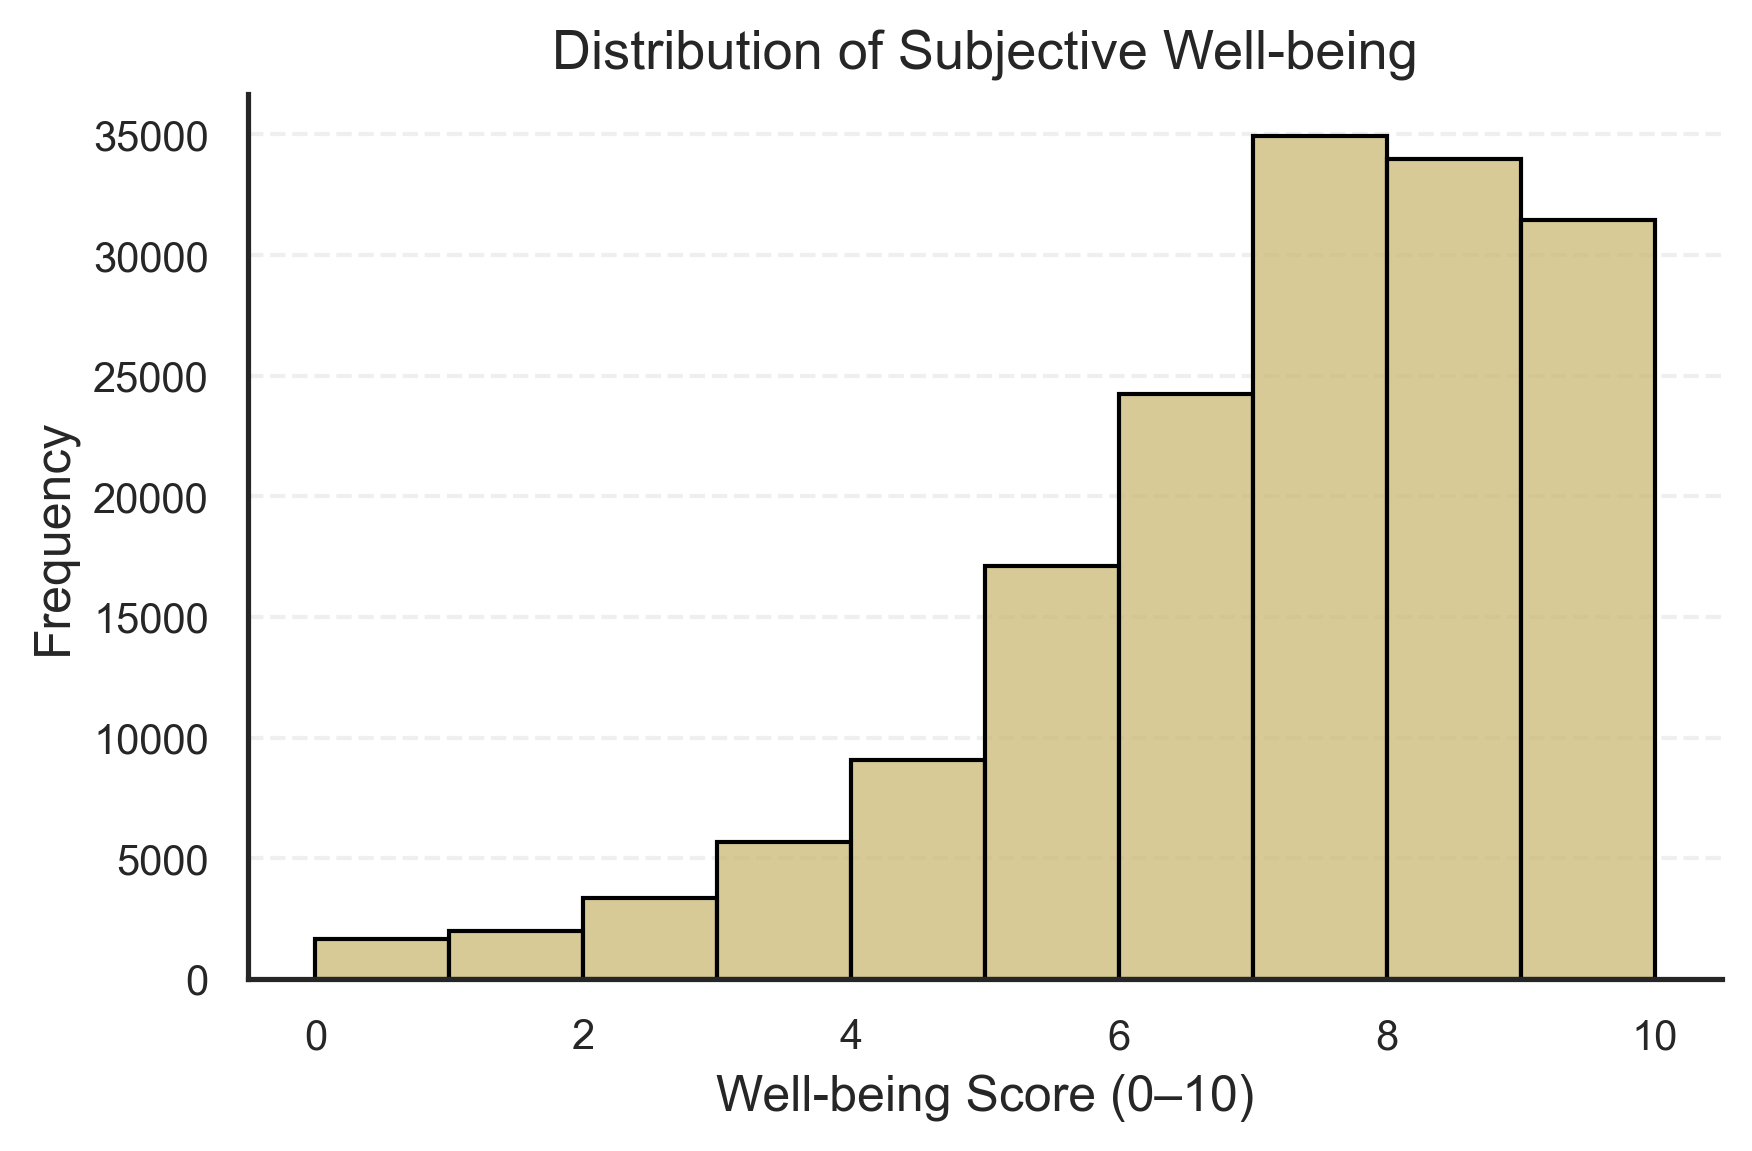

In [24]:
import os

# -------------------------
# CREATE OUTPUT DIRECTORY (if it doesn't exist)
# -------------------------
save_dir = "../reports/21-06-2026 outputs"
os.makedirs(save_dir, exist_ok=True)

# -------------------------
# GLOBAL STYLE SETTINGS
# -------------------------
sns.set_theme(style="white")

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Helper function for consistent styling
def format_axes(ax):
    sns.despine()
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Consistent color palette
colors = {
    "breadth": "#4C72B0",
    "depth": "#55A868",
    "intensity": "#C44E52",
    "accessibility": "#8172B3",
    "wellbeing": "#CCB974"
}

# -------------------------
# FIGURE 1: BREADTH
# -------------------------
fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    clean_model_df['total_breadth'],
    binwidth=1,
    color=colors["breadth"],
    edgecolor='black',
    alpha=0.85,
    ax=ax
)

ax.set_title("Distribution of Cultural Participation Breadth")
ax.set_xlabel("Number of distinct activities")
ax.set_ylabel("Frequency")
format_axes(ax)

plt.tight_layout()
plt.savefig(f"{save_dir}/fig_4_1_breadth.png")
plt.show()


# -------------------------
# FIGURE 2: DEPTH
# -------------------------
fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    clean_model_df['total_depth'],
    bins=100,
    color=colors["depth"],
    edgecolor='black',
    alpha=0.75,
    ax=ax
)

ax.set_title("Distribution of Cultural Participation Volume")
ax.set_xlabel("Number of activity days in the past year")
ax.set_ylabel("Frequency")
format_axes(ax)

plt.tight_layout()
plt.savefig(f"{save_dir}/fig_4_2_depth.png")
plt.show()


# -------------------------
# FIGURE 3: INTENSITY
# -------------------------
fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    clean_model_df['intensity'],
    bins=100,
    color=colors["intensity"],
    edgecolor='black',
    alpha=0.75,
    ax=ax
)

ax.set_title("Distribution of Participation Intensity")
ax.set_xlabel("Intensity (normalised breadth × depth)")
ax.set_ylabel("Frequency")
format_axes(ax)

plt.tight_layout()
plt.savefig(f"{save_dir}/fig_4_3_intensity.png")
plt.show()


# -------------------------
# FIGURE 4: ACCESSIBILITY
# -------------------------
fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    clean_model_df['prox_z'],
    bins=100,
    color=colors["accessibility"],
    edgecolor='black',
    alpha=0.75,
    ax=ax
)

ax.set_title("Distribution of Accessibility to Cultural Infrastructure")
ax.set_xlabel("Accessibility (Standardised Score)")
ax.set_ylabel("Frequency")
format_axes(ax)

plt.tight_layout()
plt.savefig(f"{save_dir}/fig_4_4_accessibility.png")
plt.show()


# -------------------------
# FIGURE 5: WELL-BEING
# -------------------------
fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    wb_model_df['wellbeing'],
    binwidth=1,
    color=colors["wellbeing"],
    edgecolor='black',
    alpha=0.75,
    ax=ax
)

ax.set_title("Distribution of Subjective Well-being")
ax.set_xlabel("Well-being Score (0–10)")
ax.set_ylabel("Frequency")
format_axes(ax)

plt.tight_layout()
plt.savefig(f"{save_dir}/fig_4_5_wellbeing.png")
plt.show()

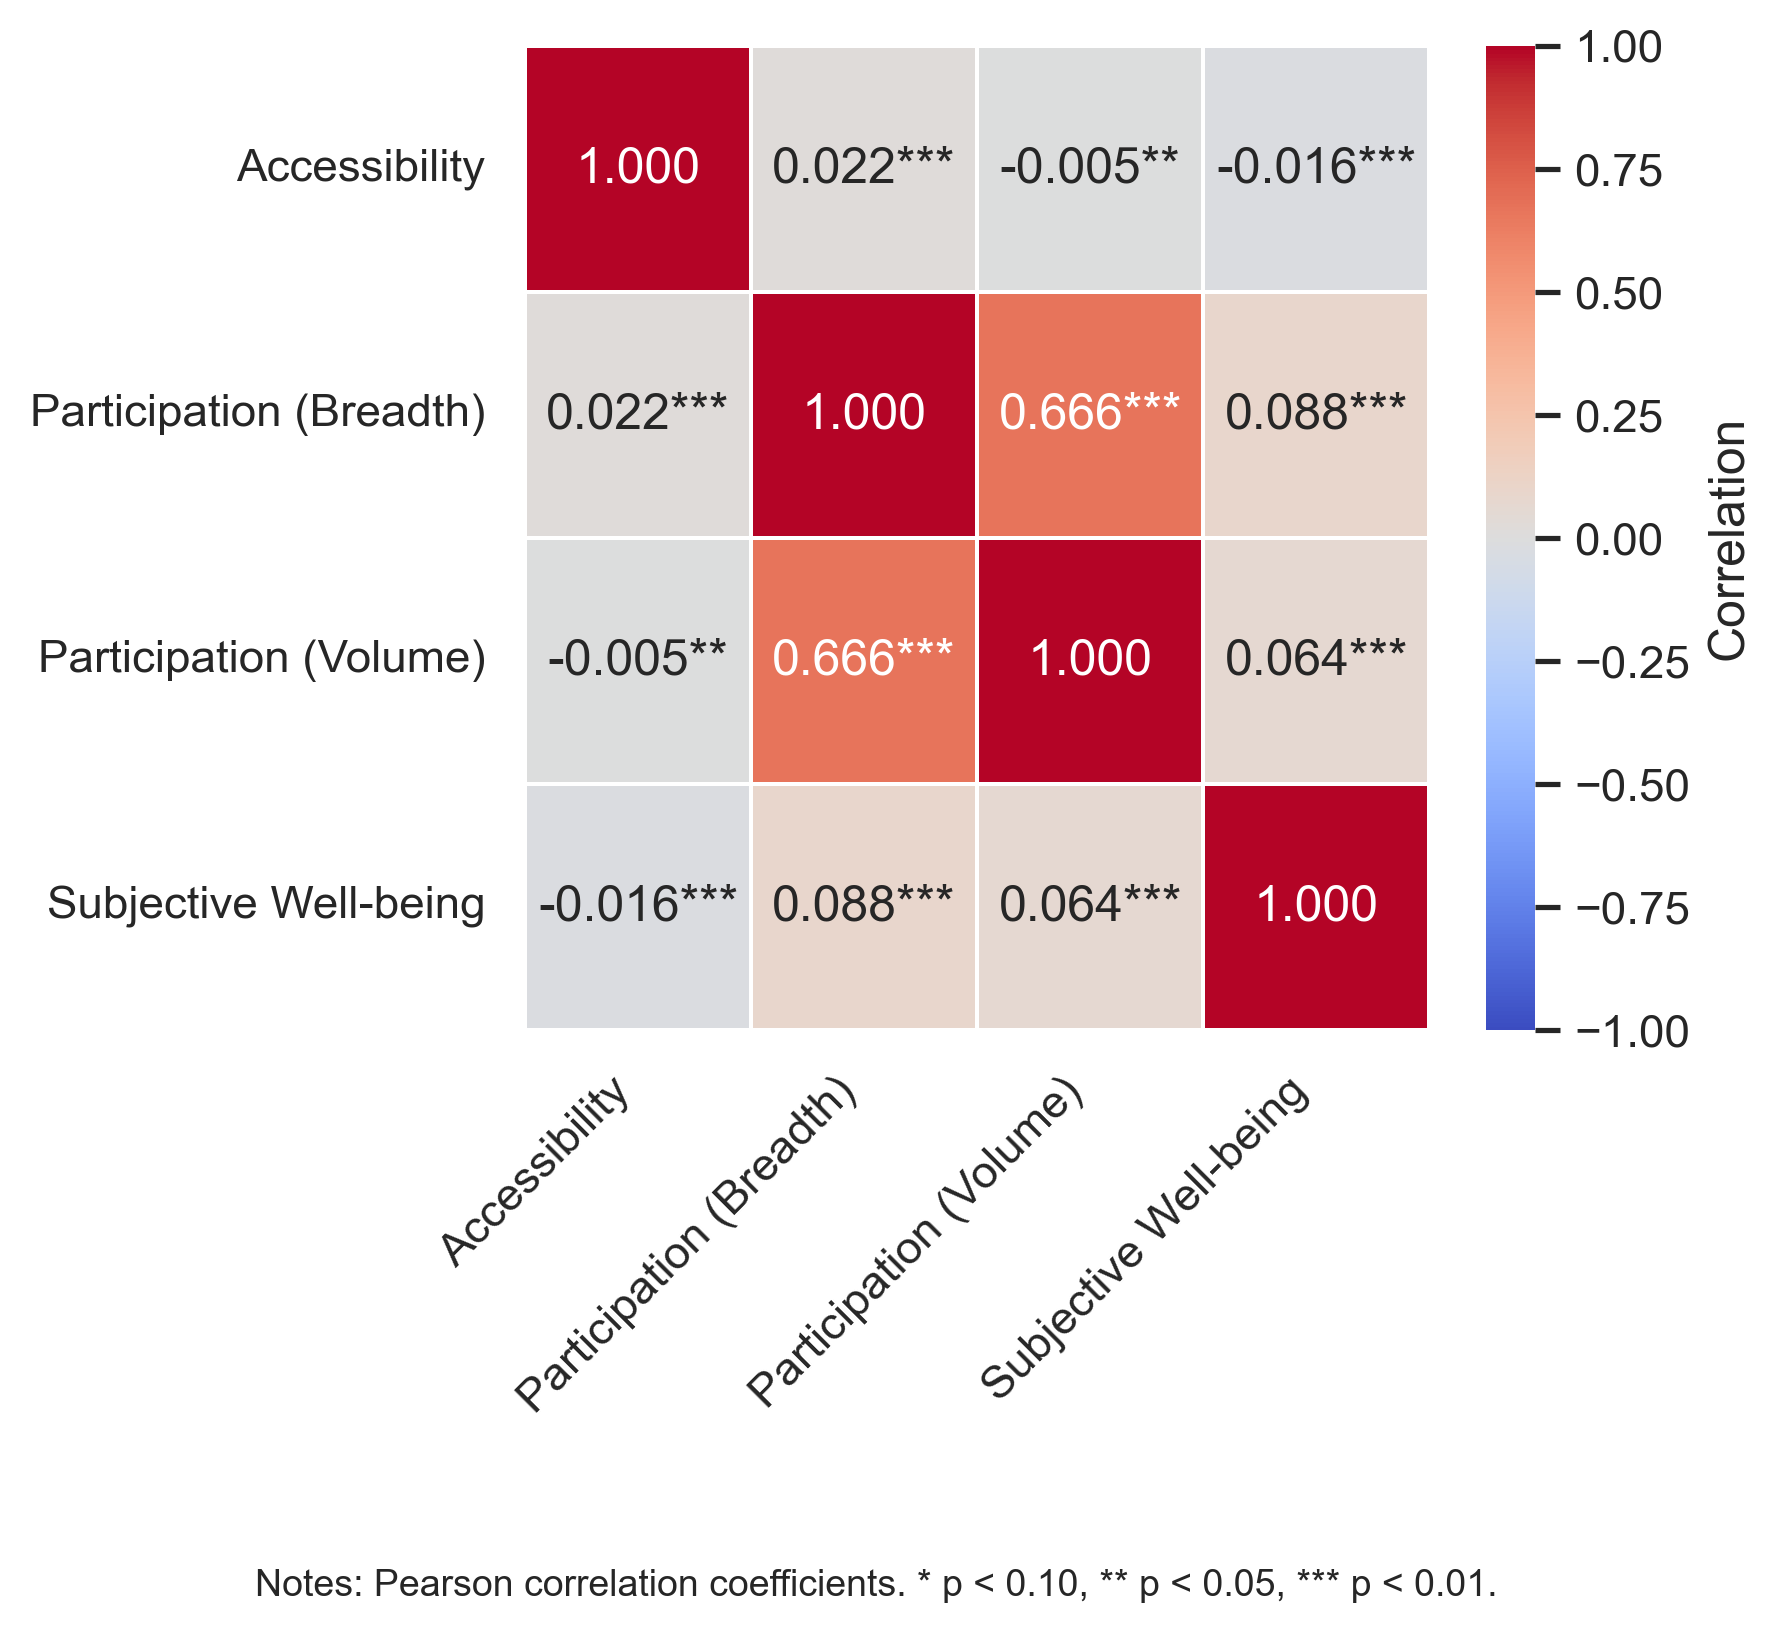

In [25]:
## Correlation figure
from scipy.stats import pearsonr

# -------------------------
# CREATE OUTPUT DIRECTORY
# -------------------------
os.makedirs(save_dir, exist_ok=True)

# -------------------------
# SELECT VARIABLES
# -------------------------
corr_vars = [
    'prox_z',
    'total_breadth',
    'total_depth',
    'wellbeing'
]

corr_df = wb_model_df[corr_vars].copy()

# -------------------------
# COMPUTE CORRELATIONS + STARS
# -------------------------
def corr_with_significance(df):
    cols = df.columns
    corr = pd.DataFrame(index=cols, columns=cols, dtype=float)
    annot = pd.DataFrame(index=cols, columns=cols, dtype=object)

    for i in cols:
        for j in cols:
            if i == j:
                corr.loc[i, j] = 1.0
                annot.loc[i, j] = "1.000"
            else:
                r, p = pearsonr(df[i], df[j])
                corr.loc[i, j] = r
                if p < 0.01:
                    stars = "***"
                elif p < 0.05:
                    stars = "**"
                elif p < 0.1:
                    stars = "*"
                else:
                    stars = ""
                annot.loc[i, j] = f"{r:.3f}{stars}"

    return corr.astype(float), annot

corr_matrix, annot_matrix = corr_with_significance(corr_df)

# -------------------------
# RENAME VARIABLES
# -------------------------
nice_names = {
    'prox_z': 'Accessibility',
    'total_breadth': 'Participation (Breadth)',
    'total_depth': 'Participation (Volume)',
    'wellbeing': 'Subjective Well-being'
}

corr_matrix.rename(index=nice_names, columns=nice_names, inplace=True)
annot_matrix.rename(index=nice_names, columns=nice_names, inplace=True)

# -------------------------
# PLOT HEATMAP
# -------------------------
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    corr_matrix,
    annot=annot_matrix,
    fmt="",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Correlation'},
    ax=ax
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# Footnote
plt.figtext(
    0.5, -0.08,
    "Notes: Pearson correlation coefficients. * p < 0.10, ** p < 0.05, *** p < 0.01.",
    ha='center',
    fontsize=9
)

# Save
plt.savefig(f"{save_dir}/correlation_heatmap.png", bbox_inches='tight')
plt.show()

### Build results tables

In [26]:
import pandas as pd
import os

# -----------------------------
# 1. Build table (same as before)
# -----------------------------
def build_model_table(model, model_name):
    df = pd.DataFrame({
        'Variable': model.params.index,
        'Coefficient': model.params,
        'P-value': model.pvalues
    })

    def stars(p):
        if p < 0.01: return "***"
        elif p < 0.05: return "**"
        elif p < 0.1: return "*"
        else: return ""

    df['Coef (stars)'] = df.apply(
        lambda x: f"{x['Coefficient']:.3f}{stars(x['P-value'])}", axis=1
    )

    return df[['Variable', 'Coef (stars)']].rename(columns={'Coef (stars)': model_name})


# -----------------------------
# 2. Build + merge
# -----------------------------
nb_table = (
    build_model_table(model_1a, "Model 1a")
    .merge(build_model_table(model_2a, "Model 2a"), on="Variable", how="outer")
    .merge(build_model_table(model_1b, "Model 1b"), on="Variable", how="outer")
    .merge(build_model_table(model_2b, "Model 2b"), on="Variable", how="outer")
)

# -----------------------------
# 3. Clean names into structured columns
# -----------------------------


def parse_variable(var):
    
    # ------------------
    # Constant & main
    # ------------------
    if var == 'Intercept':
        return ('Constant', None, None)
    if var == 'prox_z':
        return ('Main', 'Accessibility', None)
    
    # ------------------
    # PARTICIPATION (OLS only)
    # ------------------
    if var == 'total_depth':
        return ('Participation', 'Participation (Volume)', None)

    if var == 'total_breadth':
        return ('Participation', 'Participation (Breadth)', None)

    # ------------------
    # Extract numeric category safely
    # ------------------
    match = re.search(r'\[T\.np\.(?:int64|float64)\(([-\d\.]+)\)\]', var)
    value = None
    if match:
        try:
            value = float(match.group(1))
        except:
            value = None

    # ------------------
    # SEX
    # ------------------
    if 'C(SEX' in var:
        if value == 2:
            return ('Gender', 'Male', 'Female')
        else:
            return ('Gender', f'Unknown ({value})', 'Female')

    # ------------------
    # AGE
    # ------------------
    age_map = {
        2: '20–24', 3: '25–29', 4: '30–34', 5: '35–39',
        6: '40–44', 7: '45–49', 8: '50–54', 9: '55–59',
        10: '60–64', 11: '65–69', 12: '70–74',
        13: '75–79', 14: '80–84', 15: '85+'
    }

    if 'C(AGE' in var:
        if value in age_map:
            return ('Age', age_map[value], '16–19')
        else:
            return ('Age', f'Unknown ({value})', '16–19')

    # ------------------
    # EDUCATION
    # ------------------
    edu_map = {
        -1: 'Missing',
        1.0: 'Higher degree',
        2.0: 'Undergraduate degree',
        3.0: 'A-level or equivalent',
        4.0: 'GCSE/O-level',
        5.0: 'Below GCSE (arts qualification)',
        6.0: 'Other arts qualification',
        7.0: 'No formal arts qualification'
    }

    if 'C(EDU' in var:
        return ('Education',
                edu_map.get(value, f'Unknown ({value})'),
                'No formal arts qualification')

    # ------------------
    # SES
    # ------------------
    ses_map = {
        -1: 'Missing',
        1: 'Managerial/professional',
        2: 'Intermediate occupations',
        3: 'Small employers/self-employed',
        4: 'Lower supervisory/technical',
        5: 'Semi-routine/routine occupations',
        6: 'Never worked/unemployed'
    }

    if 'C(SES' in var:
        return ('SES',
                ses_map.get(int(value), f'Unknown ({value})'),
                'Never worked/unemployed')

    return ('Other', var, None)



# Apply parsing
parsed = nb_table['Variable'].apply(parse_variable)
nb_table[['Group', 'Label', 'Reference']] = pd.DataFrame(parsed.tolist(), index=nb_table.index)

# -----------------------------
# 4. Build grouped table
# -----------------------------
final_rows = []

# Constant + main effect first
final_rows.append(nb_table[nb_table['Group'] == 'Constant'])
main_header = pd.DataFrame({
    'Variable': ['Main variables'],
    'Model 1a': [''],
    'Model 2a': [''],
    'Model 1b': [''],
    'Model 2b': ['']
})
final_rows.append(main_header)
final_rows.append(nb_table[nb_table['Group'] == 'Main'])


# Order of control blocks
order = ['Age', 'Gender', 'Education', 'SES']
ctrl_header = pd.DataFrame({
    'Variable': ['Controls'],
    'Model 1a': [''],
    'Model 2a': [''],
    'Model 1b': [''],
    'Model 2b': ['']
})
final_rows.append(ctrl_header)

for g in order:
    sub = nb_table[nb_table['Group'] == g]
    if sub.empty:
        continue

    ref = sub['Reference'].dropna().iloc[0]

    # Header row
    header = pd.DataFrame({
        'Variable': [f"{g} (ref: {ref})"],
        'Model 1b': [''],
        'Model 2b': [''],
        'Model 1a': [''],
        'Model 2a': ['']
    })

    # Replace label with nice category names
    sub = sub.copy()
    sub['Variable'] = sub['Label']

    final_rows.append(header)
    final_rows.append(sub[['Variable', 'Model 1b', 'Model 2b', 'Model 1a', 'Model 2a']])

# Combine everything
nb_table_final = pd.concat(final_rows, ignore_index=True)

# -----------------------------
# 5. Add controls row
# -----------------------------
controls_info = pd.DataFrame({
    'Variable': ['Controls included'],
    'Model 1b': ['No'],
    'Model 2b': ['Yes'],
    'Model 1a': ['No'],
    'Model 2a': ['Yes']
})

nb_table_final = pd.concat([nb_table_final, controls_info], ignore_index=True)[
    ['Variable', 'Model 1b', 'Model 2b', 'Model 1a', 'Model 2a']]

# -----------------------------
# 6. Save
# -----------------------------
os.makedirs(save_dir, exist_ok=True)
nb_table_final.to_excel(f"{save_dir}/nb_table.xlsx", index=False)

In [27]:
# -----------------------------
# 1. Build + merge models
# -----------------------------
t1 = build_model_table(model_3a, "Model 3a")
t2 = build_model_table(model_3b, "Model 3b (Volume)")
t3 = build_model_table(model_3c, "Model 3c (Breadth)")

ols_table = t1.merge(t2, on="Variable", how="outer")
ols_table = ols_table.merge(t3, on="Variable", how="outer")


# -----------------------------
# 3. Parse variable names
# -----------------------------

parsed = ols_table['Variable'].apply(parse_variable)
ols_table[['Group', 'Label', 'Reference']] = pd.DataFrame(parsed.tolist(), index=ols_table.index)


# -----------------------------
# 4. Build grouped table
# -----------------------------
final_rows = []

# ---- Model structure ----
header_block = pd.DataFrame({
    'Variable': ['Model structure'],
    'Model 3a': [''],
    'Model 3b (Volume)': [''],
    'Model 3c (Breadth)': ['']
})

const_rows = ols_table[ols_table['Group'] == 'Constant'].copy()
const_rows['Variable'] = 'Constant'

final_rows.append(header_block)
final_rows.append(const_rows[['Variable', 'Model 3a', 'Model 3b (Volume)', 'Model 3c (Breadth)']])

# ---- Main + participation ----
main_header = pd.DataFrame({
    'Variable': ['Main variables'],
    'Model 3a': [''],
    'Model 3b (Volume)': [''],
    'Model 3c (Breadth)': ['']
})

main_rows = ols_table[ols_table['Group'].isin(['Main', 'Participation'])].copy()
main_rows['Variable'] = main_rows['Label']

final_rows.append(main_header)
final_rows.append(main_rows[['Variable', 'Model 3a', 'Model 3b (Volume)', 'Model 3c (Breadth)']])

# ---- Controls ----
order = ['Age', 'Gender', 'Education', 'SES']
ctrl_header = pd.DataFrame({
    'Variable': ['Controls'],
    'Model 3a': [''],
    'Model 3b (Volume)': [''],
    'Model 3c (Breadth)': ['']
})
final_rows.append(ctrl_header)

for g in order:
    sub = ols_table[ols_table['Group'] == g].copy()
    if sub.empty:
        continue

    ref = sub['Reference'].dropna().iloc[0]

    header = pd.DataFrame({
        'Variable': [f"{g} (ref: {ref})"],
        'Model 3a': [''],
        'Model 3b (Volume)': [''],
        'Model 3c (Breadth)': ['']
    })

    sub['Variable'] = sub['Label']

    final_rows.append(header)
    final_rows.append(sub[['Variable', 'Model 3a', 'Model 3b (Volume)', 'Model 3c (Breadth)']])

# Combine
ols_table_final = pd.concat(final_rows, ignore_index=True)


# -----------------------------
# 5. Add controls row
# -----------------------------
controls_row = pd.DataFrame({
    'Variable': ['Controls included'],
    'Model 3a': ['Yes'],
    'Model 3b (Volume)': ['Yes'],
    'Model 3c (Breadth)': ['Yes']
})

ols_table_final = pd.concat([ols_table_final, controls_row], ignore_index=True)


# -----------------------------
# 6. Clean final output
# -----------------------------
ols_table_final = ols_table_final[
    ['Variable', 'Model 3a', 'Model 3b (Volume)', 'Model 3c (Breadth)']
]


# -----------------------------
# 7. Save to Excel
# -----------------------------
os.makedirs(save_dir, exist_ok=True)
ols_table_final.to_excel(f"{save_dir}/ols_table.xlsx", index=False)